In [74]:
import string

import matplotlib.pyplot as plt

In [75]:
import pandas as pd

In [76]:
video_comments = pd.read_csv('video_comments.csv', encoding='utf-8')

In [77]:
sentiment_class_counts = video_comments['Sentiment'].value_counts()
print(sentiment_class_counts)

Sentiment
Negative    939
Neutral     897
Positive    847
Name: count, dtype: int64


In [79]:
video_comments = video_comments.dropna(subset=['Sentiment'])

In [80]:
sentiment_class_counts = video_comments['Sentiment'].value_counts()
print(sentiment_class_counts)

Sentiment
Negative    939
Neutral     897
Positive    847
Name: count, dtype: int64


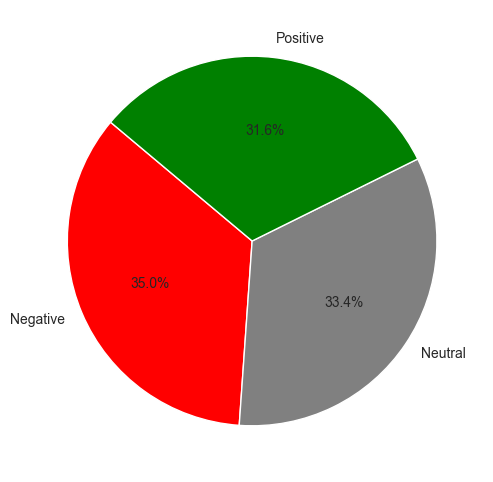

In [82]:
plt.figure(figsize=(8,6))
plt.pie(sentiment_class_counts, labels=sentiment_class_counts.index, autopct='%1.1f%%',
    startangle=140,
    colors=['red', 'gray', 'green'],
    explode=(0, 0, 0))
plt.show()

Sentiment    Negative  Neutral  Positive
VideoID                                 
0IcPQ7hoQFY        32       33        35
1zxPBQFkLe0        36       37        27
6t6ve6JZnyQ        45       23        31
987w6WSpOZo        33       13        25
9D80aDige8U        37       32        31
ARgssj7iqCM        38       27        35
Aja2KfuoqGA        32       43        25
AmDjY7s-EVo        35       20        45
AqoPQHAHbdk         2        2         4
B3g-W7v-52Q        31       31        38
DcKWQrnC7u8        34       39        27
EpcyfUBnbyM        53       24        23
I4Q1B-JCgSg         7       20        73
KKOTuUuYJ90        14       23        10
NXzVtMJeSew        19       38        24
NbDW-AmRQfA        31       47        22
SI31vyCLgjE        39       29        32
XnkIqBiXPrE        39       36        25
Yhr4ZDUVzcM        43       31        26
_88Mya6YiOg        34       31        35
a_dpHeYgtvg        48       26        26
dbpT_esVdvc        33       34        33
dpLr8cMFeiM     

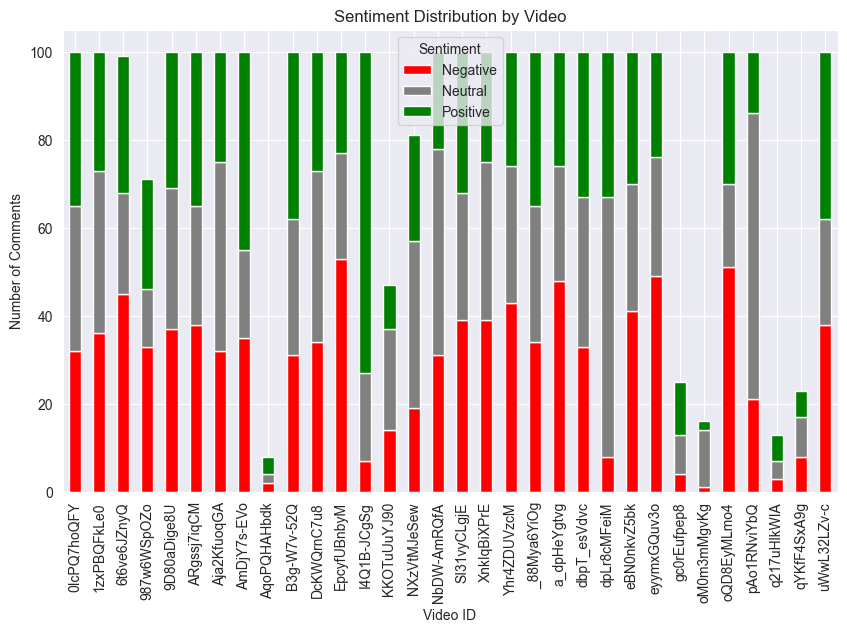

In [83]:
import seaborn as sns

# Group data by Video ID and Sentiment
video_sentiment = video_comments.groupby(['VideoID', 'Sentiment']).size().unstack()
print(video_sentiment)
# Stacked bar chart
video_sentiment.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'gray', 'green'])
plt.title('Sentiment Distribution by Video')
plt.xlabel('Video ID')
plt.ylabel('Number of Comments')
plt.legend(title='Sentiment')
plt.show()


In [84]:
import ast
video_comments['Polarity Score'] = video_comments['Polarity Score'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

video_comments['Compound'] = video_comments['Polarity Score'].apply(
    lambda x: x['compound'] if isinstance(x, dict) and 'compound' in x else None
)

top_positive_comments = video_comments[video_comments['Sentiment'] == 'Positive'].sort_values(by='Compound', ascending=False).head(3)
top_negative_comments = video_comments[video_comments['Sentiment'] == 'Negative'].sort_values(by='Compound', ascending=False).head(3)
top_neutral_comments = video_comments[video_comments['Sentiment'] == 'Neutral'].sort_values(by='Compound', ascending=False).head(3)

top_positive_comments['Comment'].head()

823     Because like the tooth fairy ect. we both know...
2154    8 rounds total<br><br>Round 1,2,3 &gt; Jake is...
1529    Why you just don&#39;t go around thinking that...
Name: Comment, dtype: object

In [85]:
top_negative_comments['Comment'].head()

2248    Netflix has failed... Although prepaid, no cha...
1663    &quot;He knows how to pick his fights&quot; ye...
1432            It was like 60M stream they crash Netflix
Name: Comment, dtype: object

In [86]:
top_neutral_comments['Comment'].head()

1085    Tyson is exhausted from chasing him around all...
2182    It was more like training session than a fight. 😂
1614    😂😂😂😂😂😂 the amount of desperado of wanting this...
Name: Comment, dtype: object

In [89]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import nltk
import string

def preprocess_comment(comment):
    comment =  str(comment)
    comment = comment.lower()
    comment = comment.translate(str.maketrans('', '', string.punctuation))
    tokens = nltk.word_tokenize(comment)
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmatized_tokens)

In [90]:
video_comments['Preprocessed Comment'] = video_comments['Comment'].apply(preprocess_comment)
video_comments[['Preprocessed Comment', 'Comment', 'Sentiment']].head()

,Preprocessed Comment,Comment,Sentiment
0,memalukan bergelut dengan lansia,Memalukan !! Bergelut dengan lansia.,Neutral
1,anyone 2025 😍,Anyone 2025 !- !!😍.,Neutral
2,shi must scripted 1000000000000000000000000per...,That shi must of been scripted 100000000000000...,Neutral
3,sad circus fight,Sad. It was a circus not a fight.,Negative
4,hello beautiful,Hello there beautiful,Positive


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = video_comments['Preprocessed Comment']
y = video_comments['Sentiment']

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(X)


In [92]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [93]:
X_train.shape

(2146, 28509)

In [94]:
X_test.shape

(537, 28509)

In [95]:
y_train.shape

(2146,)

In [97]:
y_test.shape

(537,)

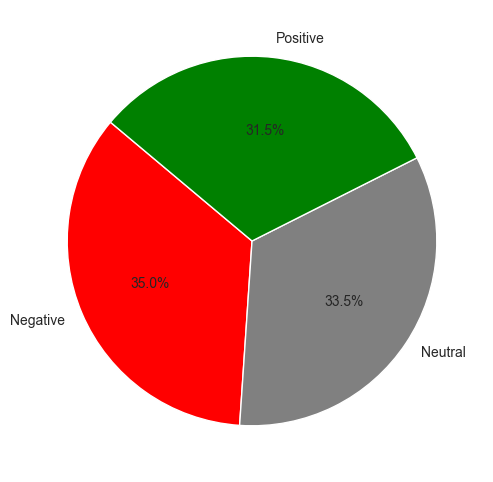

In [98]:
y_train_class_counts = y_train.value_counts()
plt.figure(figsize=(8,6))
plt.pie(y_train_class_counts, labels=y_train_class_counts.index, autopct='%1.1f%%',
    startangle=140,
    colors=['red', 'gray', 'green'],
    explode=(0, 0, 0))
plt.show()

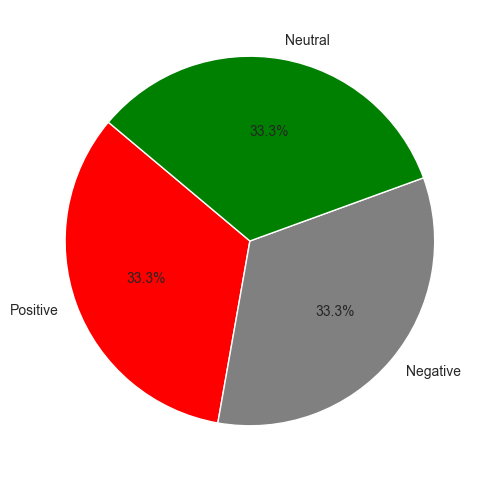

In [100]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

y_train_resampled_class_counts = y_train_resampled.value_counts()
plt.figure(figsize=(8,6))
plt.pie(y_train_resampled_class_counts, labels=y_train_resampled_class_counts.index, autopct='%1.1f%%',
    startangle=140,
    colors=['red', 'gray', 'green'],
    explode=(0, 0, 0))
plt.show()

In [101]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Classifier 1: Multinomial Naive Bayes with N-gram vectorization
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_resampled, y_train_resampled)
nb_y_pred = nb_classifier.predict(X_test)

# Classifier 2: Logistic Regression with N-gram vectorization
lr_classifier = LogisticRegression()
lr_classifier.fit(X_train_resampled, y_train_resampled)
lr_y_pred = lr_classifier.predict(X_test)

In [102]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("MultinomialNB Accuracy: ", accuracy_score(y_test, nb_y_pred))
print("LogisticRegression: ", accuracy_score(y_test, lr_y_pred))
print()
print("MultinomialNB Classification Report: ", classification_report(y_test, nb_y_pred))
print("LogisticRegression Classification Report: ", classification_report(y_test, nb_y_pred))

MultinomialNB Accuracy:  0.6797020484171322
LogisticRegression:  0.7132216014897579

MultinomialNB Classification Report:                precision    recall  f1-score   support

    Negative       0.63      0.82      0.71       187
     Neutral       0.86      0.50      0.63       178
    Positive       0.65      0.71      0.68       172

    accuracy                           0.68       537
   macro avg       0.71      0.68      0.67       537
weighted avg       0.71      0.68      0.67       537

LogisticRegression Classification Report:                precision    recall  f1-score   support

    Negative       0.63      0.82      0.71       187
     Neutral       0.86      0.50      0.63       178
    Positive       0.65      0.71      0.68       172

    accuracy                           0.68       537
   macro avg       0.71      0.68      0.67       537
weighted avg       0.71      0.68      0.67       537



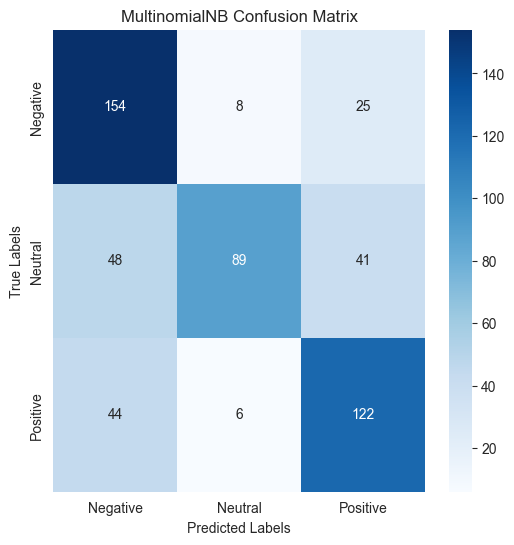

In [103]:
conf_matrix = confusion_matrix(y_test, nb_y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("MultinomialNB Confusion Matrix")
plt.show()

In [ ]:
conf_matrix = confusion_matrix(y_test, nb_y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("LogisticRegression Confusion Matrix")
plt.show()

In [ ]:
import logging

logging.basicConfig(level=logging.INFO)

logging.info(f"Data shape after loading: {data.shape}")
data = data.dropna(subset=['Comment'])
logging.info(f"Data shape after dropping null comments: {data.shape}")
data['Preprocessed Comment'] = data['Comment'].apply(preprocess_comment)
data = data.dropna(subset=['Preprocessed Comment'])
logging.info(f"Data shape after preprocessing comments: {data.shape}")
